In [1]:
!pip install pandas scikit-learn underthesea openpyxl
!pip install matplotlib seaborn

In [2]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import sparse
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
from underthesea import word_tokenize

c:\Users\Vyz\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def preprocess_text(text):
    text = str(text)
    text = re.sub(r'\\', '', text) # Xóa ký tự gạch chéo ngược
    text = re.sub(r'(?<=[a-zA-Z])\.(?=[a-zA-Z])', '', text) # Xóa dấu chấm trong các từ viết tắt
    text = word_tokenize(text, format="text") # Tách từ (VD:y_tế)
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

def read_excel_if_exists(path):
    if os.path.exists(path):
        return pd.read_excel(path, engine='openpyxl')
    return None

In [4]:
df_train = pd.read_csv('train.csv', encoding='utf-8', low_memory=False)
df_val = pd.read_csv('val.csv', encoding='utf-8', low_memory=False)
df_test = pd.read_csv('test.csv', encoding='utf-8', low_memory=False)

final_feats = read_excel_if_exists('final_dataset_with_features.xlsx')

for d in [df_train, df_val, df_test]:
    if 'processed_text' not in d.columns:
        d['title'] = d.get('title', '').astype(str)
        d['content'] = d.get('content', '').astype(str)
        d['full_text'] = d['title'] + " " + d['content']
        d['processed_text'] = d['full_text'].apply(preprocess_text)
    if 'target' not in d.columns:
        if 'label' in d.columns:
            d['target'] = d['label'].map({'REAL': 0, 'FAKE': 1})


In [5]:
def merge_features(base_df, features_df):
    if features_df is None:
        return base_df, []
    if 'id' in base_df.columns and 'id' in features_df.columns: # Ghép dữ liệu dựa trên id hoặc title
        merged = base_df.merge(features_df, on='id', how='left', suffixes=(None, '_feat'))
    elif 'title' in base_df.columns and 'title' in features_df.columns:
        merged = base_df.merge(features_df, on='title', how='left', suffixes=(None, '_feat'))
    else:
        return base_df, []
    # Loại bỏ các cột dạng văn bản, chỉ dữ lịa các cột tính năng dạng số
    exclude = set(['title', 'content', 'full_text', 'processed_text', 'label', 'target', 'id', 'label_id'])
    feature_cols = []
    for c in merged.columns:
        if c in exclude:
            continue
        if c.endswith('_feat') and c[:-5] in merged.columns:
            continue
        if pd.api.types.is_numeric_dtype(merged[c]):
            feature_cols.append(c)
    return merged, feature_cols

df_train, train_feature_cols = merge_features(df_train, final_feats)
df_val, val_feature_cols = merge_features(df_val, final_feats)
df_test, test_feature_cols = merge_features(df_test, final_feats)

print(f"Kích thước tập (Train/Val/Test): {len(df_train)}, {len(df_val)}, {len(df_test)}")
print('Các tính năng số học phát hiện được:', train_feature_cols)


Kích thước tập (Train/Val/Test): 10417, 2232, 2233
Các tính năng số học phát hiện được: ['text_length', 'title_length', 'uppercase_ratio', 'exclamation_count', 'question_count', 'clickbait_score', 'sentiment_score']


In [6]:
# Kiểm tra trùng lặp / leakage giữa các split
for name, df in [('train', df_train), ('val', df_val), ('test', df_test)]:
    dup_count = df.duplicated(subset=['processed_text', 'target']).sum()
    print(f"Số dòng trùng lặp trong tập {name}: {dup_count}")

for (name1, df1), (name2, df2) in [(('train', df_train), ('test', df_test)), (('train', df_train), ('val', df_val)), (('val', df_val), ('test', df_test))]:
    common = pd.merge(df1, df2, on=['processed_text', 'target'], how='inner')
    print(f"Số mẫu bị lọt giữa tập {name1} và {name2}: {len(common)}")

Số dòng trùng lặp trong tập train: 0
Số dòng trùng lặp trong tập val: 0
Số dòng trùng lặp trong tập test: 0
Số mẫu bị lọt giữa tập train và test: 0
Số mẫu bị lọt giữa tập train và val: 0
Số mẫu bị lọt giữa tập val và test: 0


In [7]:
print(f"Kích thước tập Train(70%): {df_train.shape[0]} mẫu")
print(f"Kích thước tập Validation(15%): {df_val.shape[0]} mẫu")
print(f"Kích thước tập Test(15%): {df_test.shape[0]} mẫu")

Kích thước tập Train(70%): 10417 mẫu
Kích thước tập Validation(15%): 2232 mẫu
Kích thước tập Test(15%): 2233 mẫu


In [8]:
# Trích xuất đặc trưng bằng TF-IDF (fit trên tập train)
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
# Chỉ fit trên tập Train để tránh gian lận rò rỉ thông tin
X_train_tfidf = vectorizer.fit_transform(df_train['processed_text'])
X_val_tfidf = vectorizer.transform(df_val['processed_text'])
X_test_tfidf = vectorizer.transform(df_test['processed_text'])

# Nếu có các đặc trưng số học bổ sung, ghép chúng vào ma trận TF-IDF
def append_numeric_features(X_tfidf, df, feature_cols):
    if feature_cols:
        numeric = df[feature_cols].fillna(0).astype(float)
        return sparse.hstack([X_tfidf, sparse.csr_matrix(numeric.values)], format='csr')
    return X_tfidf

X_train_final = append_numeric_features(X_train_tfidf, df_train, train_feature_cols)
X_val_final = append_numeric_features(X_val_tfidf, df_val, val_feature_cols)
X_test_final = append_numeric_features(X_test_tfidf, df_test, test_feature_cols)

y_train = df_train['target']
y_val = df_val['target']
y_test = df_test['target']

In [9]:
# Huấn luyện mô hình Logistic Regression
model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
model.fit(X_train_final, y_train)

c:\Users\Vyz\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [14]:
# Đánh giá mô hình và phân tích trọng số
y_pred = model.predict(X_test_final) # Mô hình dự đoán trên tập test\
y_pred_proba = model.predict_proba(X_test_final)[:, 1]
print(f"Độ chính xác (Accuracy): {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Precision (Macro Avg): {precision_score(y_test, y_pred, average='macro') * 100:.2f}%")
print(f"Recall (Macro Avg): {recall_score(y_test, y_pred, average='macro') * 100:.2f}%")
print(f"F1-score (Macro Avg): {f1_score(y_test, y_pred, average='macro') * 100:.2f}%")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba) * 100:.2f}%\n")
print(classification_report(y_test, y_pred, target_names=['REAL (0)', 'FAKE (1)']))

Độ chính xác (Accuracy): 93.42%
Precision (Macro Avg): 92.50%
Recall (Macro Avg): 93.27%
F1-score (Macro Avg): 92.86%
ROC-AUC: 97.71%

              precision    recall  f1-score   support

    REAL (0)       0.96      0.94      0.95      1446
    FAKE (1)       0.89      0.93      0.91       787

    accuracy                           0.93      2233
   macro avg       0.92      0.93      0.93      2233
weighted avg       0.94      0.93      0.93      2233



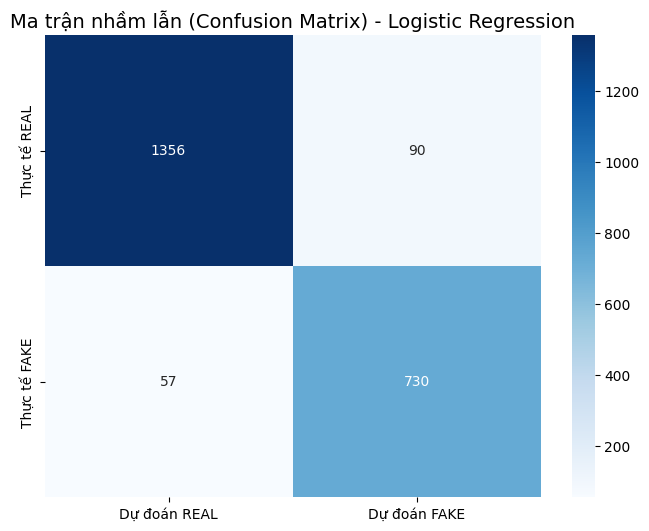

In [15]:
cm = confusion_matrix(y_test, y_pred)

# Vẽ biểu đồ trực quan hóa Ma trận nhầm lẫn
plt.figure(figsize=(8, 6)) # Thiết lập kích thước khung hình
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Dự đoán REAL', 'Dự đoán FAKE'], 
            yticklabels=['Thực tế REAL', 'Thực tế FAKE'])

plt.title('Ma trận nhầm lẫn (Confusion Matrix) - Logistic Regression', fontsize=14)
plt.show()

In [16]:
# Lấy danh sách từ vựng và nối với tên các cột số học
vocab = list(vectorizer.get_feature_names_out())
feature_names = vocab + (train_feature_cols if train_feature_cols else [])
# Lập bảng đối chiếu trọng số từ mô hình
weights = model.coef_[0]
coef_df = pd.DataFrame({'Feature': feature_names, 'Weight': weights})
coef_df = coef_df.sort_values(by='Weight')

print("Top 5 dấu hiệu của tin thật (REAL - Trọng số âm mạnh nhất):")
print(coef_df.head(5).to_string(index=False))

print("Top 5 dấu hiệu của tin thật (FAKE - Trọng số dương mạnh nhất):")
print(coef_df.tail(5).sort_values(by='Weight', ascending=False).to_string(index=False))

Top 5 dấu hiệu của tin thật (REAL - Trọng số âm mạnh nhất):
 Feature    Weight
 covid19 -7.400073
     ảnh -5.203539
    hoặc -3.277347
    2020 -3.188602
năm 2020 -3.053406
Top 5 dấu hiệu của tin thật (FAKE - Trọng số dương mạnh nhất):
     Feature   Weight
          đã 6.256580
bạn quan_tâm 6.024240
  có_thể bạn 5.994795
    quan_tâm 5.312724
         bạn 5.023643


In [17]:
# Test thử mô hình trên 1 câu nội dung mới
sample_news = "Sở Y tế TP.HCM cảnh báo số ca nhiễm coronavirus đang tăng cao, người dân cần đeo khẩu trang."
sample_processed = preprocess_text(sample_news)
sample_tfidf = vectorizer.transform([sample_processed])

if train_feature_cols:
    zero_numeric = sparse.csr_matrix([[0.0]*len(train_feature_cols)])
    sample_tfidf = sparse.hstack([sample_tfidf, zero_numeric], format='csr')
prediction = model.predict(sample_tfidf)[0]
probability = model.predict_proba(sample_tfidf)[0][1]

print(f"Nội dung test: '{sample_news}'")
print(f"Dự đoán: {'Tin giả (FAKE)' if prediction == 1 else 'Tin thật (REAL)'}")
print(f"Xác suất là tin giả: {probability * 100:.2f}%")

Nội dung test: 'Sở Y tế TP.HCM cảnh báo số ca nhiễm coronavirus đang tăng cao, người dân cần đeo khẩu trang.'
Dự đoán: Tin thật (REAL)
Xác suất là tin giả: 2.47%
